#Loading Data & Preprocessing


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
from sklearn.preprocessing import LabelEncoder
#preprocessing
import pandas as pd

#df = pd.read_csv("/content/drive/MyDrive/MLproject/InjuresQ22024 xlsx 3(Sheet1) (1).csv")
df = pd.read_csv("/InjuresQ22024 xlsx 3(Sheet1).csv")


# Drop empty columns
df = df.drop(["General", "Quarter"], axis=1)
df = df.dropna(axis=1, how='all')

# Replace '#CONNECT!' with '29 ~ 25' in 'Age Group' column
df['Age Group'] = df['Age Group'].replace('#CONNECT!', '29 ~ 25')


cat_cols = ["Sex", "Age Group",
            "Career Category", "Infection Classification","Treatment Result",
            "Cause of Injury","Office"]

label_encoders = {} # Dictionary to store encoders

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le # Store the fitted encoder

# Print the mapping for each categorical column
for col, encoder in label_encoders.items():
    print(f"\nMapping for column: {col}")
    for i, class_name in enumerate(encoder.classes_):
        print(f"{i} = {class_name}")


Mapping for column: Sex
0 = female
1 = male
2 = nan

Mapping for column: Age Group
0 = 19 ~ 15
1 = 24 ~ 20
2 = 29 ~ 25
3 = 34 ~ 30
4 = 39 ~ 35
5 = 44 ~ 40
6 = 49 ~ 45
7 = 54 ~ 50
8 = 59 ~ 55
9 = 60  =<
10 = nan

Mapping for column: Career Category
0 = Agriculture, hunting, animal husbandry and bird breeding professions
1 = Basic Engineering ProfessionsAuxiliary
2 = Industrial, Chemical and Food Processing Professions
3 = Managers and Business Managers
4 = Other Professions
5 = Sales Professions
6 = Service Professions
7 = Specialists in scientific, technical and humanitarian subjects
8 = Technicians in scientific, technical and humanitarian subjects
9 = Writing Professions
10 = nan

Mapping for column: Infection Classification
0 = Other Work Injuries
1 = Work Injuries Caused by Road Accidents
2 = nan

Mapping for column: Treatment Result
0 = Healing with incapacity
1 = Healing without helplessness
2 = The result is death.
3 = Under Treatment
4 = nan

Mapping for column: Cause of Injur

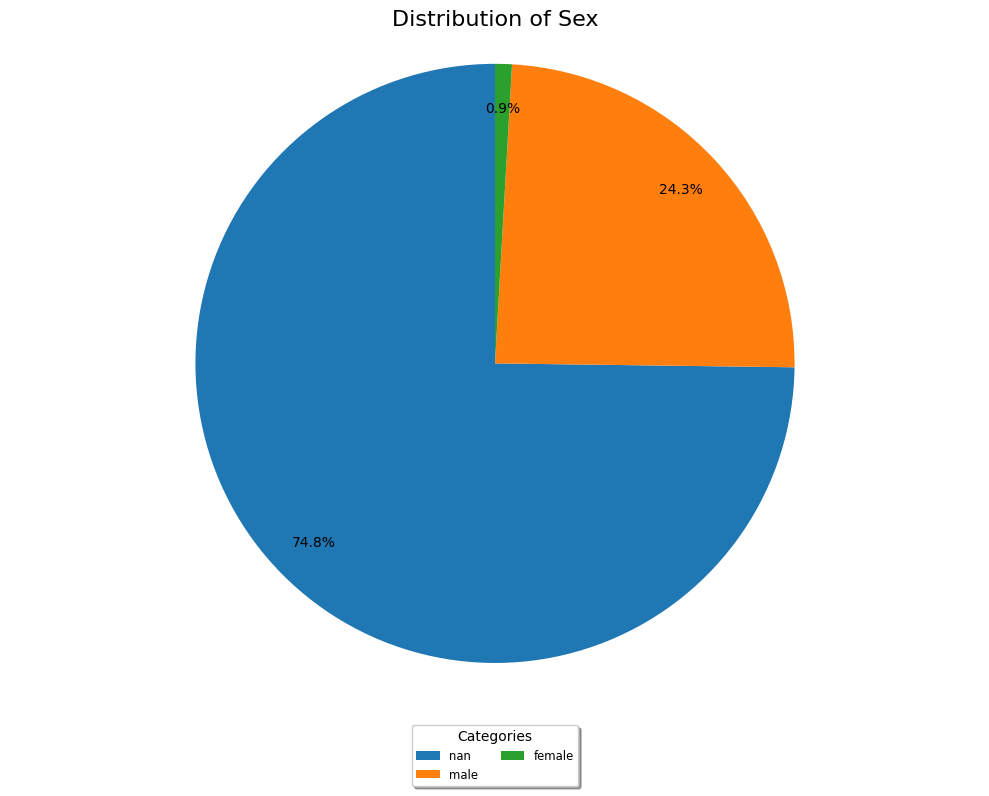

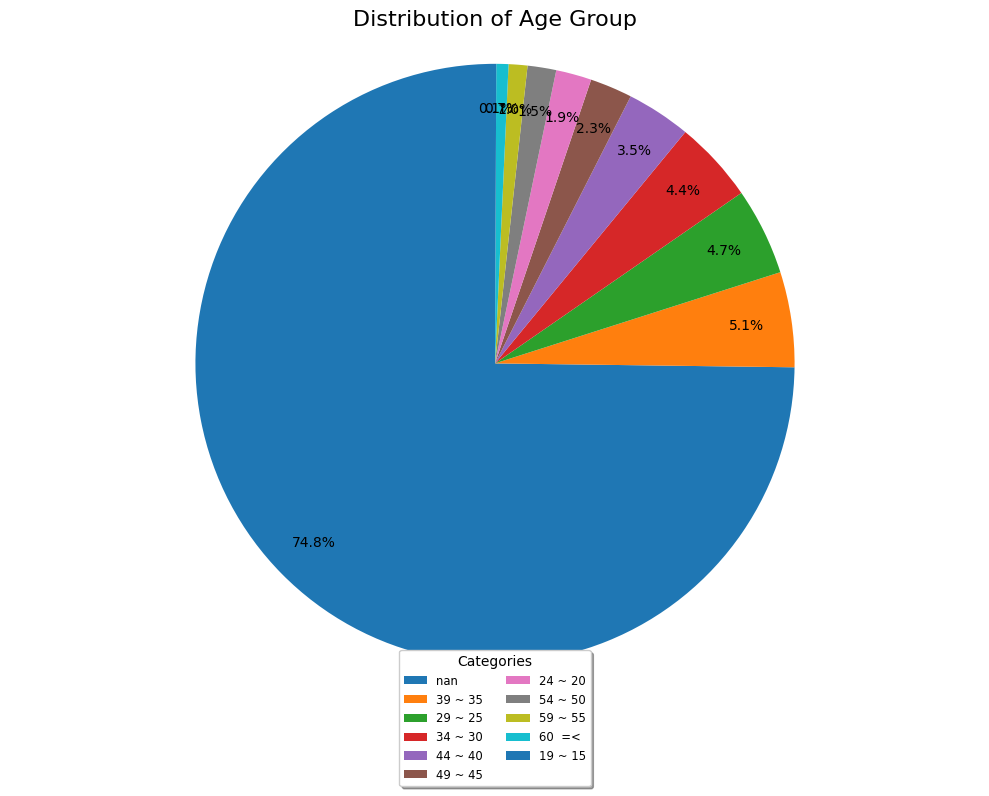

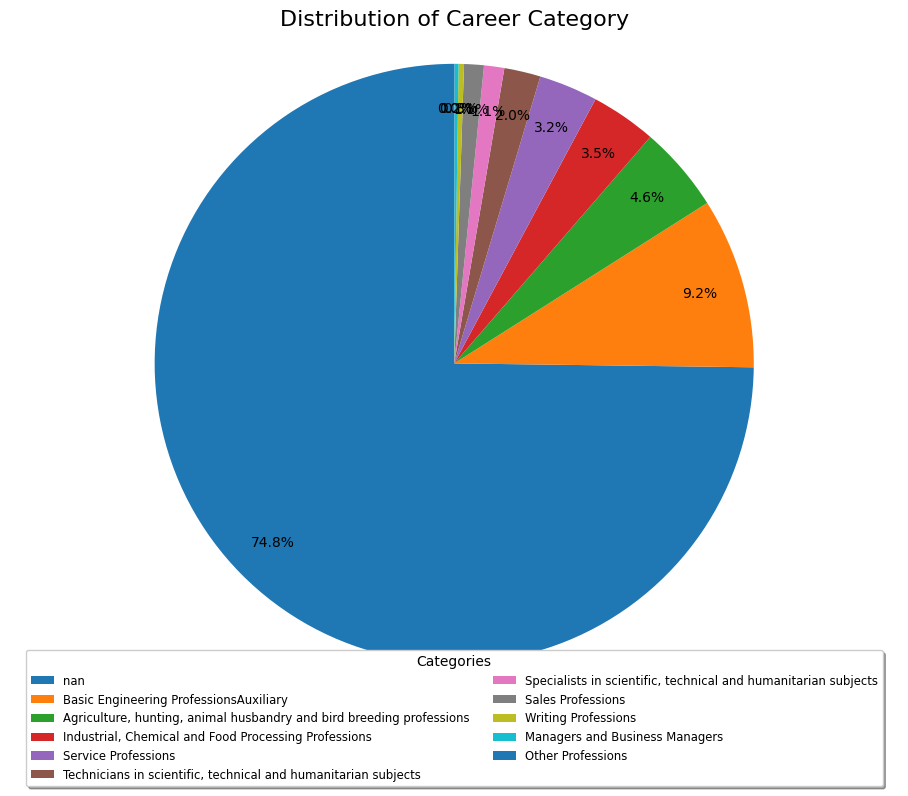

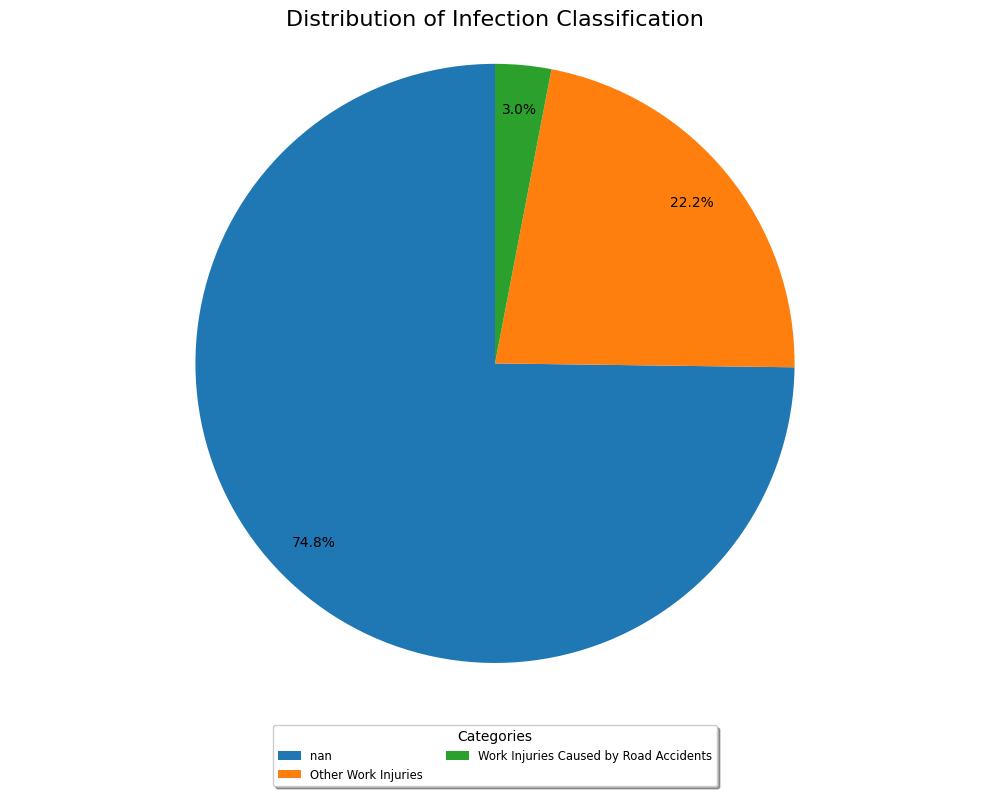

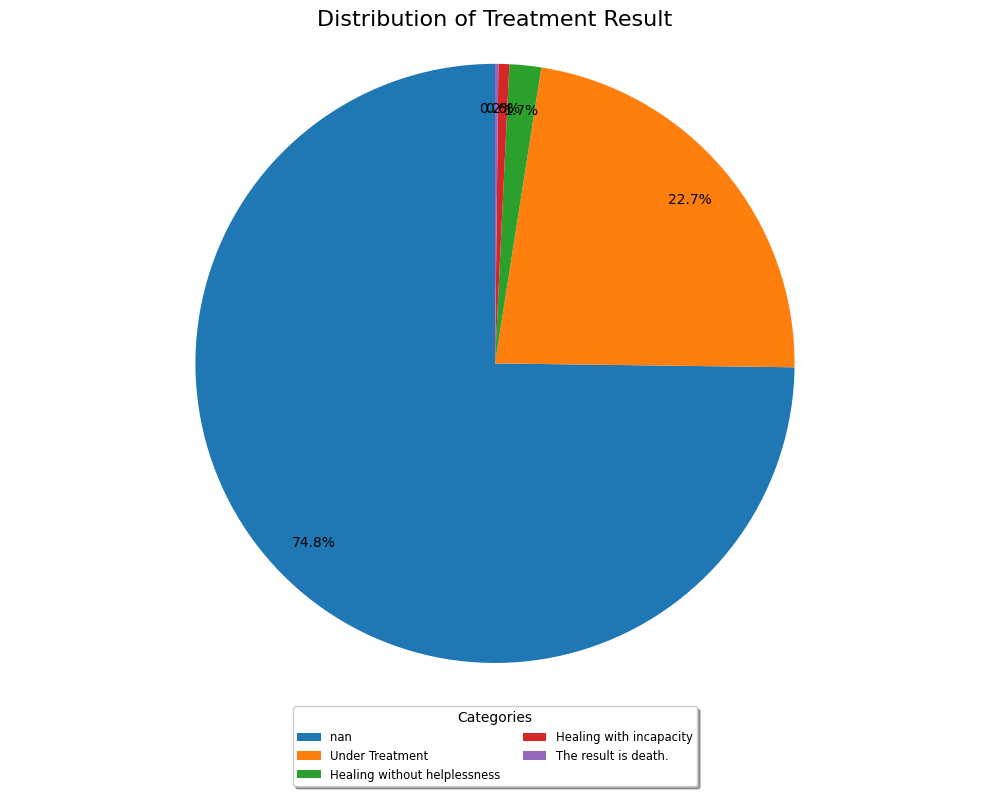

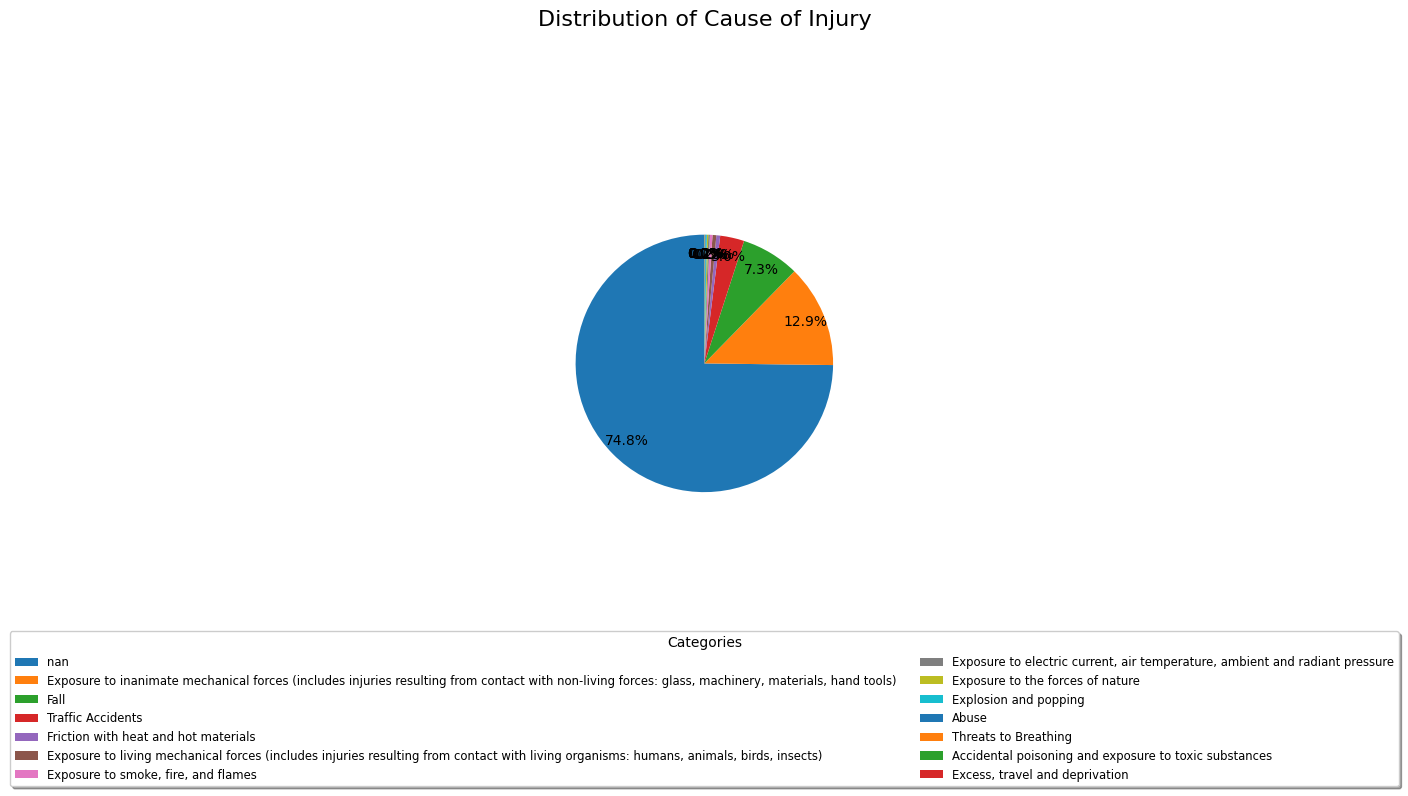

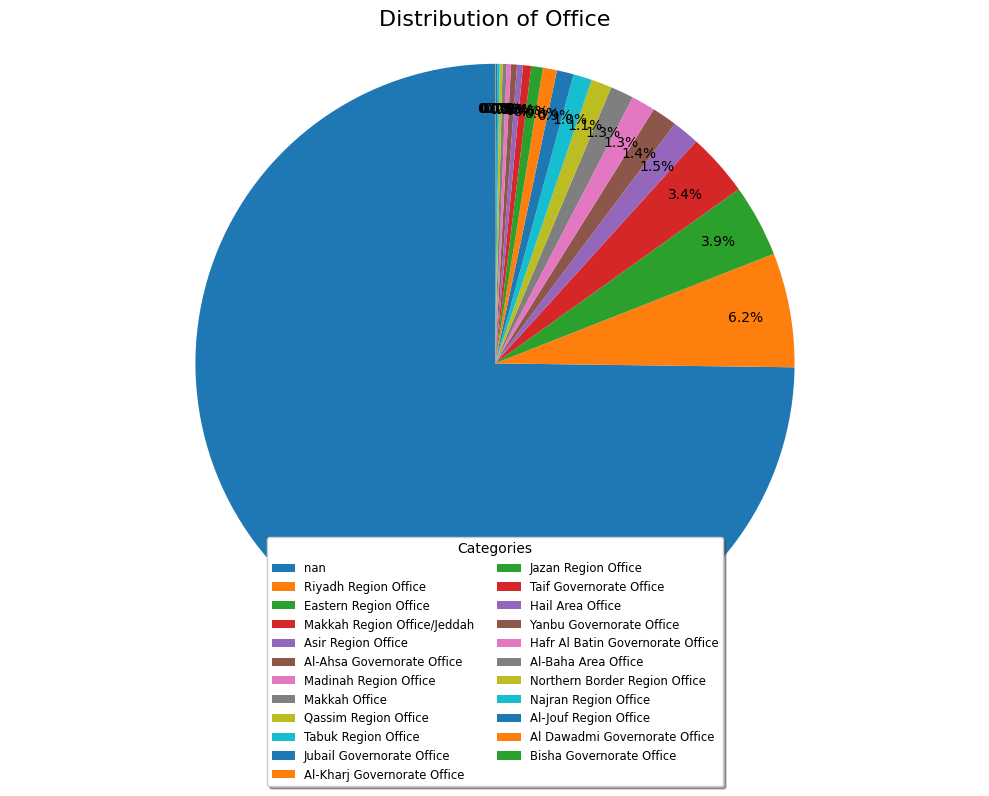

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' and 'label_encoders' are already defined from previous cells

# List of categorical columns to plot
cat_cols_for_pie_charts = ["Sex", "Age Group", "Career Category", "Infection Classification", "Treatment Result", "Cause of Injury", "Office"]

for col in cat_cols_for_pie_charts:
    if col in label_encoders:
        # Get the label encoder for the current column
        le = label_encoders[col]

        # Get the value counts of the encoded column
        value_counts = df[col].value_counts()

        # Map the encoded values back to their original labels
        # Ensure that the index of value_counts is treated as integers before inverse_transform
        labels = [le.inverse_transform([idx])[0] for idx in value_counts.index.astype(int)]

        # Create the pie chart
        plt.figure(figsize=(10, 8))
        plt.pie(value_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85) # Removed 'labels=labels'
        plt.title(f'Distribution of {col}', fontsize=16)
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

        # Add legend below the plot
        plt.legend(labels, title="Categories", loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize='small', fancybox=True, shadow=True)

        plt.tight_layout()
        plt.show()
    else:
        print(f"LabelEncoder for column '{col}' not found. Skipping pie chart for this column.")

/tmp/ipython-input-26467471.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cause_labels, y=cause_counts.values, palette='viridis')
/tmp/ipython-input-26467471.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


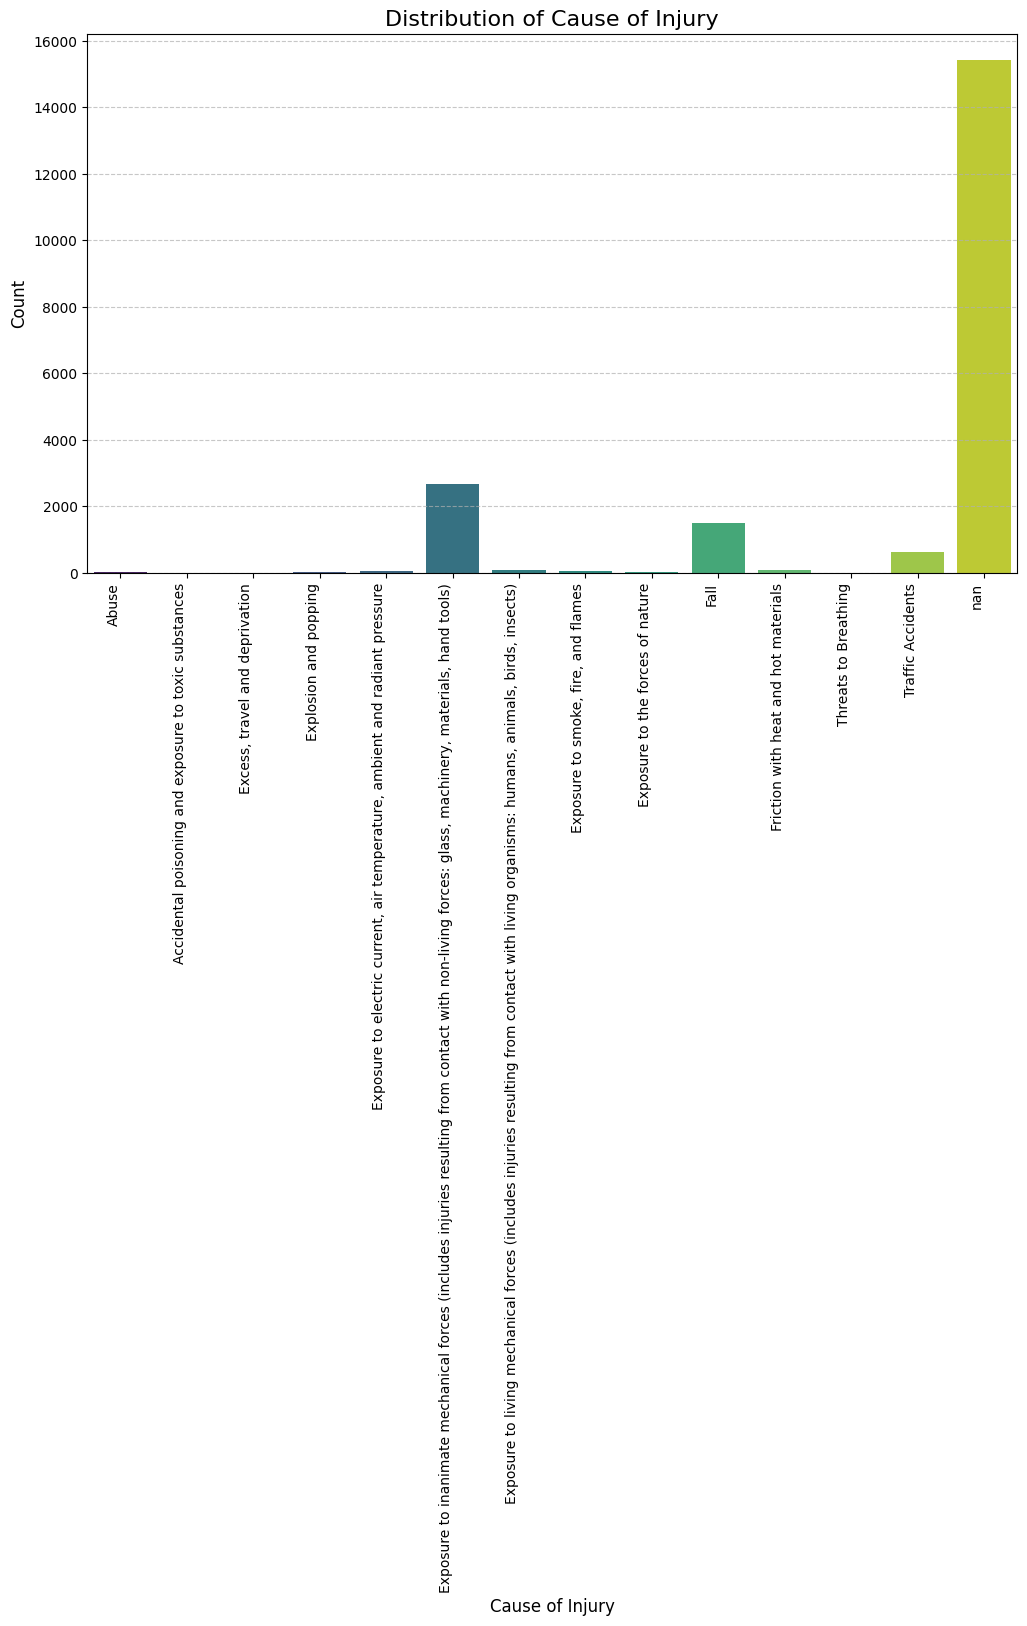

/tmp/ipython-input-26467471.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=office_labels, y=office_counts.values, palette='magma')


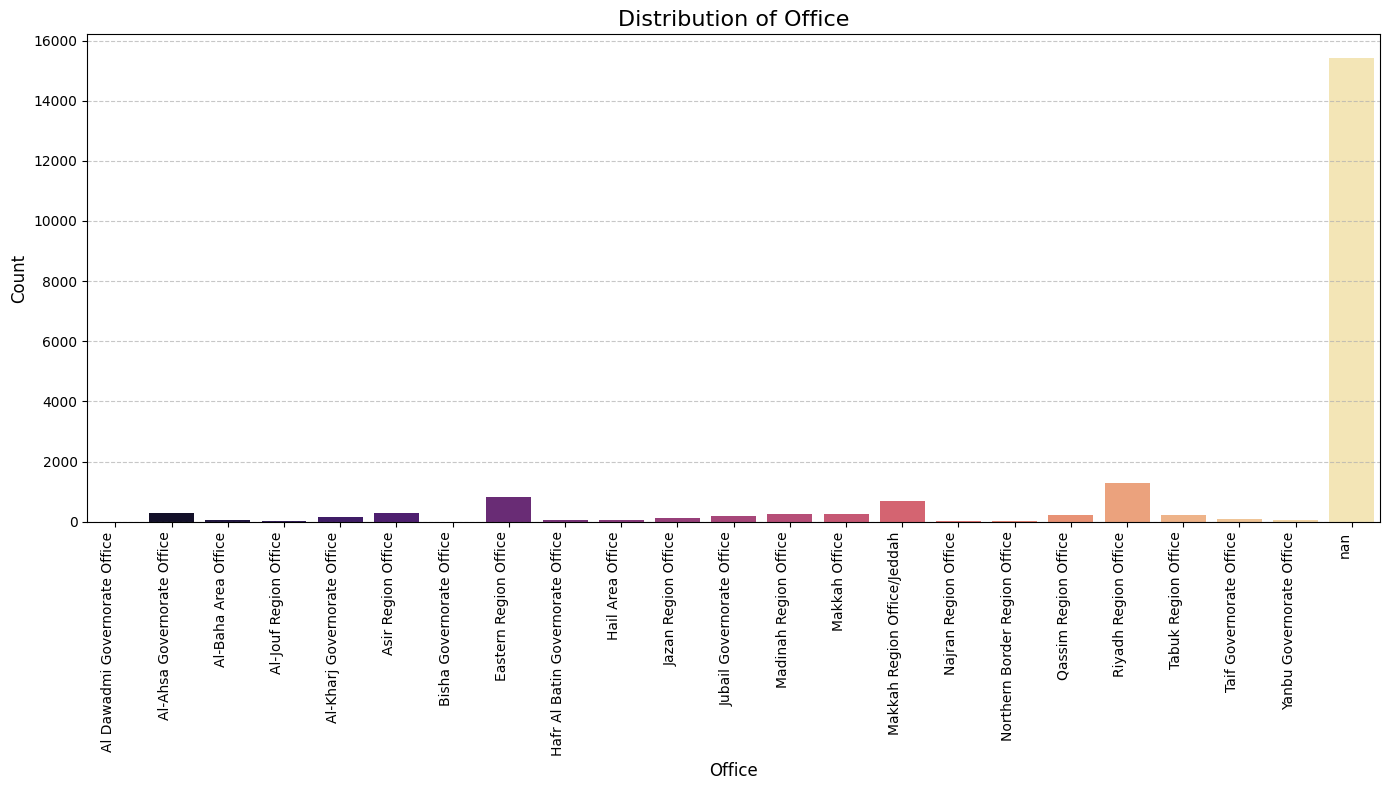

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Bar chart for 'Cause of Injury' distribution ---

# Get value counts of the encoded column
cause_counts = df['Cause of Injury'].value_counts().sort_index()

# Map encoded values back to original labels using the stored label_encoders
cause_labels = [label_encoders['Cause of Injury'].inverse_transform([idx])[0] for idx in cause_counts.index.astype(int)]

plt.figure(figsize=(12, 7))
sns.barplot(x=cause_labels, y=cause_counts.values, palette='viridis')
plt.title('Distribution of Cause of Injury', fontsize=16)
plt.xlabel('Cause of Injury', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Bar chart for 'Office' distribution ---

# Get value counts of the encoded column
office_counts = df['Office'].value_counts().sort_index()

# Map encoded values back to original labels using the stored label_encoders
office_labels = [label_encoders['Office'].inverse_transform([idx])[0] for idx in office_counts.index.astype(int)]

plt.figure(figsize=(14, 8))
sns.barplot(x=office_labels, y=office_counts.values, palette='magma')
plt.title('Distribution of Office', fontsize=16)
plt.xlabel('Office', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
selected_features = [
    "Career Category",
    "Cause of Injury",
    "Infection Classification",
    "Treatment Result",
    "Sex",
    "Age Group",
    "Number of Work Injuries",
    "Office"
]

df = df[selected_features]


# Drop rows with missing essential values
df = df.dropna(subset=["Career Category", "Cause of Injury", "Number of Work Injuries"])
df = df.fillna("Unknown")

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Convert categorical features to dummy/one-hot encoding
df_normalized = pd.get_dummies(df)

# Separate features to scale (all columns after one-hot encoding)
X = df_normalized.select_dtypes(include=['float64', 'int64', 'uint8']) # Include uint8 for dummy variables

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the first few rows of the scaled data
print("First 5 rows of scaled data:")
print(X_scaled[:5])

First 5 rows of scaled data:
[[ 1.57988335  0.71850731 -0.36885757  0.31954856 -5.17862741 -1.00353911
  -0.29201311  1.02069665]
 [ 1.57988335  0.71850731 -0.36885757  0.31954856 -5.17862741 -1.00353911
  -0.29201311 -1.29420145]
 [ 1.57988335  0.71850731 -0.36885757  0.31954856 -5.17862741 -0.5031643
  -0.29201311  1.02069665]
 [ 1.57988335  1.86938745  2.71107354  0.31954856 -5.17862741 -0.5031643
  -0.29201311  1.02069665]
 [ 1.57988335 -2.73413309 -0.36885757  0.31954856 -5.17862741 -0.5031643
  -0.29201311  1.37683482]]


In [ ]:
#the relationship between career category and cause of injury
import pandas as pd

relation_table = pd.crosstab(df["Career Category"], df["Cause of Injury"])
print(relation_table.head())


Cause of Injury  0   1   2   3   4     5   6   7   8    9   10  11   12
Career Category                                                        
0                 0   1   0  11  14   582  24  12   5  265  17   2   26
1                 7   1   1  10  16  1063  37  22  14  488  37   4  199
2                 2   0   0   3   2   288   7   3   4  210   9   0  203
3                 0   0   0   0   0    13   3   0   0   25   0   0    3
4                 0   0   0   0   0     2   0   0   0    0   0   0    2


In [ ]:
relation_table_normalized = pd.crosstab(
    df["Career Category"], df["Cause of Injury"], normalize='index'
)
print(relation_table_normalized.head())


Cause of Injury        0         1         2         3         4         5   \
Career Category                                                               
0                0.000000  0.001043  0.000000  0.011470  0.014599  0.606882   
1                0.003686  0.000527  0.000527  0.005266  0.008425  0.559768   
2                0.002736  0.000000  0.000000  0.004104  0.002736  0.393981   
3                0.000000  0.000000  0.000000  0.000000  0.000000  0.295455   
4                0.000000  0.000000  0.000000  0.000000  0.000000  0.500000   

Cause of Injury        6         7         8         9         10        11  \
Career Category                                                               
0                0.025026  0.012513  0.005214  0.276330  0.017727  0.002086   
1                0.019484  0.011585  0.007372  0.256977  0.019484  0.002106   
2                0.009576  0.004104  0.005472  0.287278  0.012312  0.000000   
3                0.068182  0.000000  0.000000  0.56

###Heat map

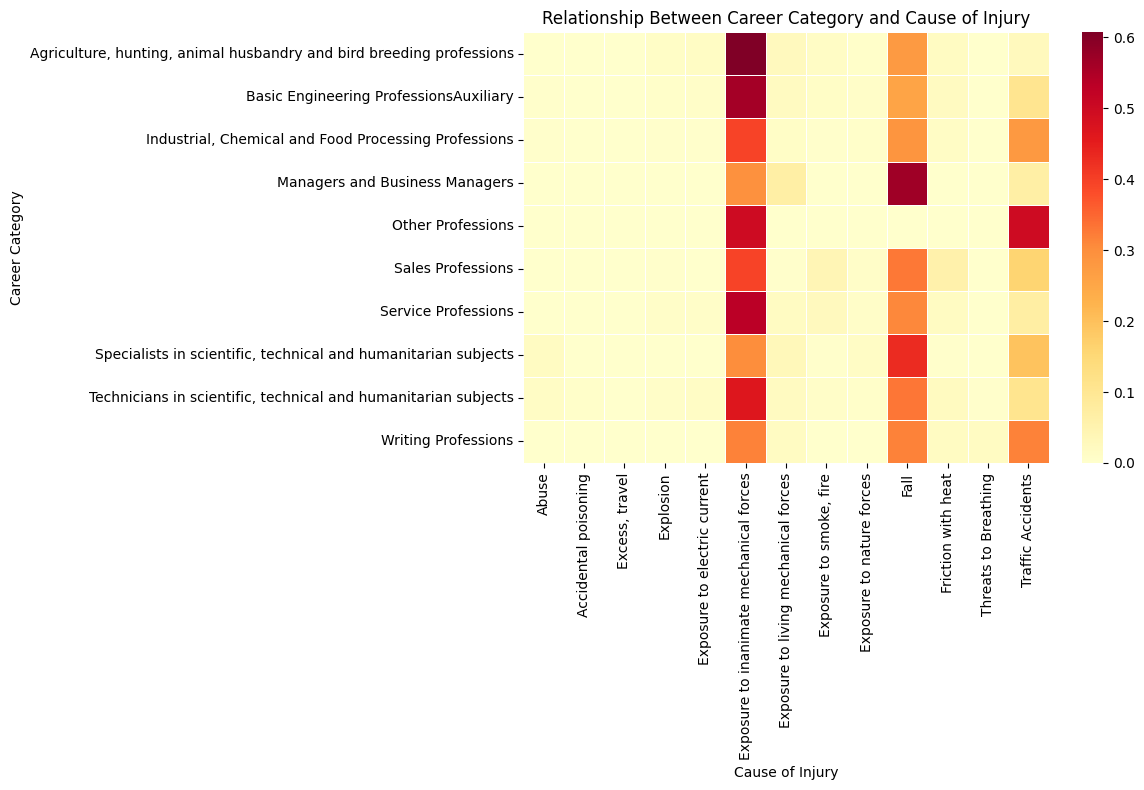

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the original mappings from the label encoders
career_category_mapping = {i: class_name for i, class_name in enumerate(label_encoders["Career Category"].classes_)}
cause_of_injury_mapping = {
    0: 'Abuse',
    1: 'Accidental poisoning',
    2: 'Excess, travel',
    3: 'Explosion',
    4: 'Exposure to electric current',
    5: 'Exposure to inanimate mechanical forces',
    6: 'Exposure to living mechanical forces',
    7: 'Exposure to smoke, fire',
    8: 'Exposure to nature forces',
    9: 'Fall',
    10: 'Friction with heat',
    11: 'Threats to Breathing',
    12: 'Traffic Accidents',
    13: 'nan'
}

# Rename the index and columns of the normalized relation table
relation_table_normalized_labeled = relation_table_normalized.rename(
    index=career_category_mapping,
    columns=cause_of_injury_mapping
)

plt.figure(figsize=(12, 8))
sns.heatmap(relation_table_normalized_labeled, cmap="YlOrRd", linewidths=0.5)
plt.title("Relationship Between Career Category and Cause of Injury")
plt.xlabel("Cause of Injury")
plt.ylabel("Career Category")
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

#Rank Features

##PCA

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Ensure all columns in df_normalized are numeric before scaling
df_normalized = pd.get_dummies(df)

# Scale all columns in df_normalized
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(df_normalized)

# Perform PCA on the scaled data
pca = PCA(n_components=X_scaled_all.shape[1])
pca.fit(X_scaled_all)

importance = np.abs(pca.components_[0])  # First principal component
ranking = pd.DataFrame({"Feature": df_normalized.columns, "Importance": importance})


ranking = ranking.sort_values(by="Importance", ascending=False)
print(ranking)

                    Feature  Importance
1           Cause of Injury    0.676414
2  Infection Classification    0.666016
0           Career Category    0.207095
4                       Sex    0.158553
6   Number of Work Injuries    0.120087
5                 Age Group    0.104303
3          Treatment Result    0.072591
7                    Office    0.017064



##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Cause of Injury", axis=1)
y = df["Cause of Injury"]

# Convert categorical features to dummy/one-hot encoding
X = pd.get_dummies(X, drop_first=True)

model = RandomForestClassifier(random_state=42)
model.fit(X, y)


RandomForestClassifier(random_state=42)

###Feature Importance

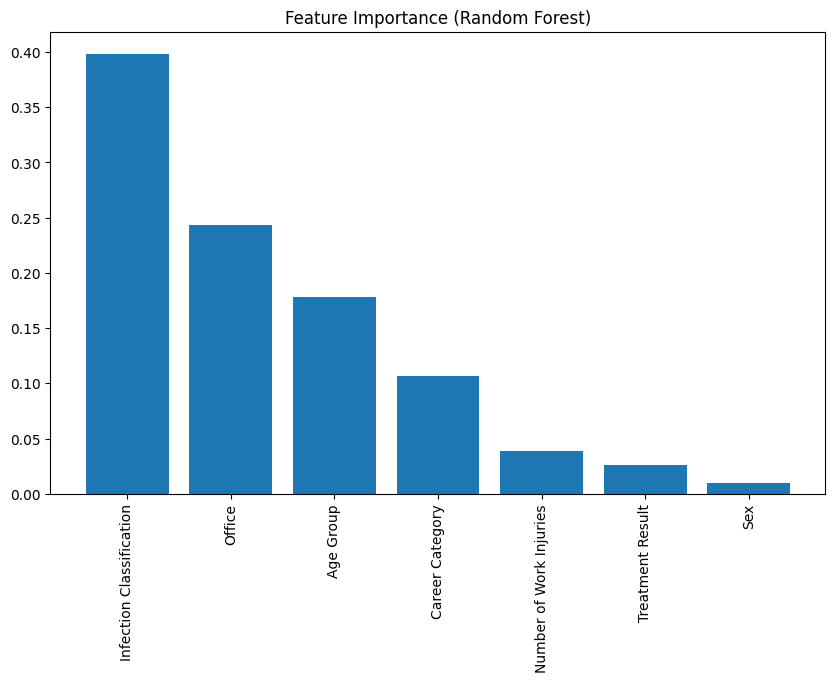

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [X.columns[i] for i in indices], rotation=90)
plt.show()


The PCA-based feature ranking identified Cause of Injury and Infection Classification as the most variable features in the dataset, suggesting they contribute most to overall diversity.

In contrast, the Random Forest model ranked Office (region) as the most important feature, indicating that regional differences are highly predictive of injury causes.

This difference arises because PCA is an unsupervised method focusing on variance, while Random Forest is supervised and focuses on predictive importance relative to the target variable.


#Classification (Random Forest Classifier)

In [ ]:
# === Classification: Predict 'Treatment Result' (no data cleaning) ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd



# Filter df based on selected_features
df_filtered = df[selected_features].copy()

# Drop rows with missing essential values ( simplified from earlier steps)
df_filtered.dropna(subset=["Career Category", "Cause of Injury", "Number of Work Injuries", "Treatment Result"], inplace=True)


target_col = "Treatment Result"  # الهدف

# Use all other columns as features
features = [col for col in df_filtered.columns if col != target_col]


X = df_filtered[features].copy()
y = df_filtered[target_col].copy()


# Identify and handle rare classes in the target variable
class_counts = y.value_counts()
rare_classes = class_counts[class_counts < 2].index

# Remove rows with rare classes from X and y
X_filtered = X[~y.isin(rare_classes)]
y_filtered = y[~y.isin(rare_classes)]


# Separate features by type for preprocessing
cat_features = [col for col in X_filtered.columns if X_filtered[col].dtype == 'object']
num_features = [col for col in X_filtered.columns if X_filtered[col].dtype != 'object']


# Preprocessing pipeline: One-hot encode categorical features, pass through numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features),
    ],
    remainder="drop" # Drop columns not specified in transformers
)

# Split data into training and testing sets using the filtered data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered # Use filtered data and stratify on filtered y
)

# Define and train the model pipeline
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=18, min_samples_split=4, min_samples_leaf=2, class_weight="balanced_subsample", random_state=42, n_jobs=-1))
])

model_pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = model_pipeline.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, y_pred, average="weighted", zero_division=0), 3))
print("F1-score :", round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 3))
print("\nDetailed Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.747
Precision: 0.845
Recall   : 0.747
F1-score : 0.79

Detailed Report:
               precision    recall  f1-score   support

           0       0.08      0.29      0.12        24
           1       0.12      0.20      0.15        71
           2       0.00      0.00      0.00         7
           3       0.93      0.81      0.86       939

    accuracy                           0.75      1041
   macro avg       0.28      0.32      0.28      1041
weighted avg       0.84      0.75      0.79      1041



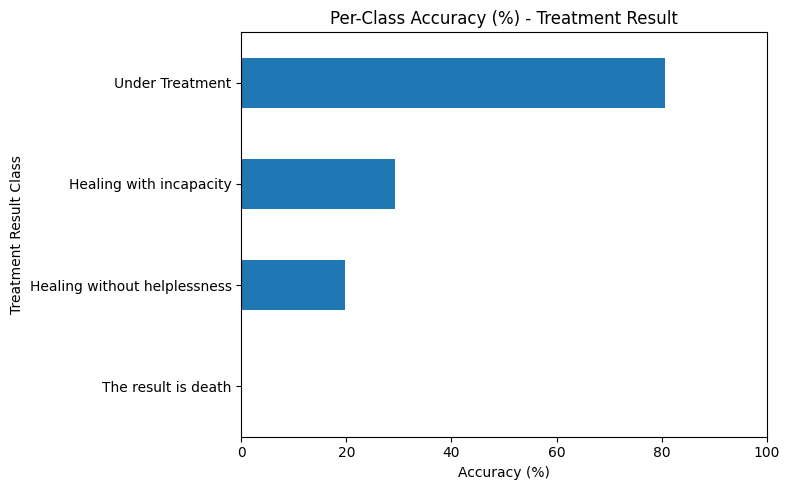

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Mapping for Treatment Result
treatment_mapping = {
    0: "Healing with incapacity",
    1: "Healing without helplessness",
    2: "The result is death",
    3: "Under Treatment",
    4: "nan"
}

# تحويل الأرقام إلى أسماء
y_test_named = y_test.map(treatment_mapping)
y_pred_named = pd.Series(y_pred, index=y_test.index).map(treatment_mapping)
# داتا فريم للمقارنة
plot_df = pd.DataFrame({
    "Actual": y_test_named,
    "Predicted": y_pred_named
})

# هل التوقع صحيح؟
plot_df["Correct"] = (plot_df["Actual"] == plot_df["Predicted"])

# إجمالي الحالات لكل كلاس + عدد الصحيحة
total_per_class   = plot_df.groupby("Actual")["Correct"].count()
correct_per_class = plot_df.groupby("Actual")["Correct"].sum()

# دقة كل كلاس (%)
acc_per_class = (correct_per_class / total_per_class * 100)

# رسم bar أفقي
plt.figure(figsize=(8, 5))
acc_per_class.sort_values().plot(kind="barh")  # from low to high

plt.title("Per-Class Accuracy (%) - Treatment Result")
plt.xlabel("Accuracy (%)")
plt.ylabel("Treatment Result Class")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


######A classification model was used because the target variable contains categorical values, such as:

-Under Treatment

-Recovery

-Death

-Disability

In other words, the model’s job is to assign each record to one of these categories, not to predict a numeric value.
The model correctly predicted about 75% of all cases.

A Precision of 0.84 shows that most predicted labels were correct.

Recall of 0.75 means the model successfully captured most of the true cases.

F1-score of 0.79 indicates a good balance between precision and recall.

#Clustering (K-Means)



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


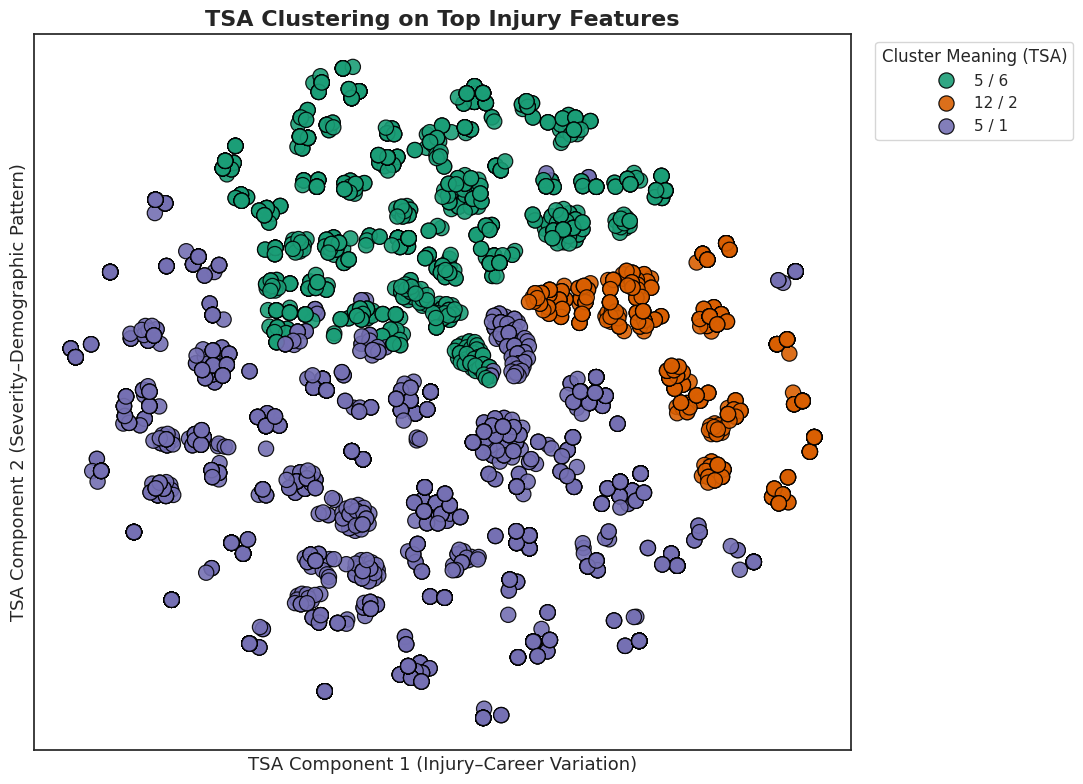

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1) أهم الفيتشرات ==========
top_features = [
    "Cause of Injury",
    "Career Category",
    "Infection Classification",
    "Age Group"
]

# نستخدم فقط الفيتشرز الموجودة فعلاً في df
top_features = [c for c in top_features if c in df.columns]
df_tsa = df[top_features].dropna().copy()

# ========== 2) Label Encoding ==========
enc = {}
for col in df_tsa.columns:
    le = LabelEncoder()
    df_tsa[col] = le.fit_transform(df_tsa[col].astype(str))
    enc[col] = le

# ========== 3) Scaling ==========
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_tsa)

# ========== 4) K-Means داخل TSA ==========
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
df_tsa["Cluster"] = kmeans.fit_predict(X_scaled)

# ========== 5) تسمية الكلسترز زي كود كي مينس ==========
cluster_labels = {}

for c in range(k):
    subset = df_tsa[df_tsa["Cluster"] == c]

    # أهم سبب إصابة داخل الكلستر
    cause_idx = subset["Cause of Injury"].value_counts().idxmax()
    main_cause = enc["Cause of Injury"].inverse_transform([cause_idx])[0]

    # أهم فئة مهنية داخل الكلستر
    career_idx = subset["Career Category"].value_counts().idxmax()
    main_career = enc["Career Category"].inverse_transform([career_idx])[0]

    # اسم الكلستر النهائي
    cluster_labels[c] = f"{main_cause} / {main_career}"

# نحط الاسم بدل رقم الكلستر
df_tsa["Cluster_Label"] = df_tsa["Cluster"].map(cluster_labels)

# ========== 6) t-SNE (TSA Visualization) ==========
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate=250,
    n_iter=1500,
    random_state=42
)

tsne_res = tsne.fit_transform(X_scaled)
df_tsa["TSA1"] = tsne_res[:, 0]
df_tsa["TSA2"] = tsne_res[:, 1]

# ========== 7) رسم TSA نظيف مع أسماء واضحة ==========
plt.figure(figsize=(11, 8))
sns.set_theme(style="white")

sns.scatterplot(
    data=df_tsa,
    x="TSA1",
    y="TSA2",
    hue="Cluster_Label",     # <-- مو رقم، اسم واضح
    palette="Dark2",
    s=120,
    edgecolor="black",
    alpha=0.9
)

plt.title("TSA Clustering on Top Injury Features", fontsize=16, fontweight="bold")

# تسمية المحاور (احترافية للبحث العلمي)
plt.xlabel("TSA Component 1 (Injury–Career Variation)", fontsize=13)
plt.ylabel("TSA Component 2 (Severity–Demographic Pattern)", fontsize=13)

# نخفي الأرقام لتظهر الصورة نظيفة
plt.xticks([])
plt.yticks([])

plt.legend(title="Cluster Meaning (TSA)",
           bbox_to_anchor=(1.02, 1),
           loc="upper left")

plt.tight_layout()
plt.show()


Model evaluation


(Accuracy, Recall, Precision, F1-score)

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import mode
import numpy as np

# ===== 1) نستخدم سبب الإصابة للتقييم =====
true_labels = df_km["Cause of Injury"].values   # <-- هنا التغيير المهم

# ===== 2) التوقعات من K-Means =====
predicted_clusters = df_km["Cluster"].values

# ===== 3) ربط كل كلستر بأكثر سبب إصابة داخله =====
labels_map = {}
for c in np.unique(predicted_clusters):
    mask = predicted_clusters == c
    majority_label = mode(true_labels[mask], keepdims=True).mode[0]
    labels_map[c] = majority_label

# تطبيق الخريطة على كل القيم
mapped_predictions = np.array([labels_map[c] for c in predicted_clusters])

# ===== 4) حساب المقاييس =====
accuracy = accuracy_score(true_labels, mapped_predictions)
precision = precision_score(true_labels, mapped_predictions, average="weighted", zero_division=0)
recall = recall_score(true_labels, mapped_predictions, average="weighted", zero_division=0)
f1 = f1_score(true_labels, mapped_predictions, average="weighted", zero_division=0)

# ===== 5) عرض النتائج =====
print("📊 Model Evaluation Metrics (K-Means using Cause of Injury)")
print("-----------------------------------------------------------")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-score : {f1 * 100:.2f}%")


NameError: name 'df_km' is not defined

#Association Rule Mining (Apriori)


Model Used: Apriori Association Rule Mining.

Reason for Selection: To find relationships between job categories and causes of injuries (unsupervised learning).

Features Used:

Career Category

Cause of Injury

Preprocessing: One-hot encoding for categorical data.

Main Findings:

Basic Engineering → Exposure to mechanical forces (Conf. 0.56)

Industrial & Chemical → Traffic Accidents (Lift 2.32)

Specialists → Fall (Conf. 0.43)

Evaluation Metrics:

Support → rule frequency

Confidence → reliability (acts like accuracy)

Lift → strength of the relationship

In [ ]:
# --- Association Rules (Apriori): Career Category -> Cause of Injury ---

from mlxtend.frequent_patterns import apriori, association_rules

career_col = "Career Category"
cause_col  = "Cause of Injury"

# 1) Recover original string labels (inverse from your fitted LabelEncoders)
df_assoc = pd.DataFrame({
    career_col: label_encoders[career_col].inverse_transform(df[career_col].astype(int)),
    cause_col : label_encoders[cause_col].inverse_transform(df[cause_col].astype(int)),
})

# 2) Clean and ensure string dtype
df_assoc = df_assoc.dropna(subset=[career_col, cause_col]).astype(str)

# 3) One-hot encode (required by Apriori)
df_ohe = pd.get_dummies(df_assoc)

# 4) Mine frequent itemsets (pairs only to focus on Career↔Cause)
frequent_itemsets = apriori(
    df_ohe,
    min_support=0.01,   # ↓ lower to 0.005 or 0.001 if you get few/no rules
    use_colnames=True,
    max_len=2
)

# 5) Generate rules using confidence
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2    # ↓ lower (e.g., 0.1) to see more rules
)

# 6) Keep only: (one Career) -> (one Cause)
def _is_career(s): return all(x.startswith(f"{career_col}_") for x in s)
def _is_cause(s):  return all(x.startswith(f"{cause_col}_")  for x in s)

rules = rules[
    rules["antecedents"].apply(lambda a: len(a)==1 and _is_career(a)) &
    rules["consequents"].apply(lambda c: len(c)==1 and _is_cause(c))
].copy()

# 7) Sort and display
rules = rules.sort_values(["confidence", "support", "lift"], ascending=False)

print("\n📊 Top Association Rules (Career → Cause):")
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))

# (Optional) Pretty print as readable text lines
def pretty_rule(row):
    ant = list(row["antecedents"])[0].split(f"{career_col}_", 1)[1]
    con = list(row["consequents"])[0].split(f"{cause_col}_", 1)[1]
    return f"If {career_col} = {ant} → {cause_col} = {con} (support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f})"

print("\nTop rules (readable):")
for _, r in rules.head(10).iterrows():
    print(pretty_rule(r))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# اختاري أقوى 10 قواعد من حيث الـ Confidence
top_rules = rules.sort_values(by='confidence', ascending=False).head(10)

# تجهيز أسماء القواعد (المهنة → سبب الإصابة)
rule_labels = [
    f"{list(a)[0].split('_',1)[1]} → {list(c)[0].split('_',1)[1]}"
    for a, c in zip(top_rules['antecedents'], top_rules['consequents'])
]

# ضبط التنسيق العام
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

# رسم عمودين: واحد للـ Confidence وواحد للـ Support
bar_width = 0.4
x = range(len(top_rules))

plt.barh([i + bar_width/2 for i in x], top_rules['confidence'], height=bar_width, label='Confidence', color='royalblue')
plt.barh([i - bar_width/2 for i in x], top_rules['support'], height=bar_width, label='Support', color='lightcoral')

# عناوين ومحاور
plt.yticks(x, rule_labels)
plt.xlabel('Value')
plt.title('Top 10 Association Rules (Support vs Confidence)', fontsize=14, fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()  # عشان الأقوى يكون بالأعلى
plt.tight_layout()
plt.show()


#Vector Machine

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
df = pd.read_csv("InjuresQ22024 xlsx 3(Sheet1).csv")

# Select features and target
X = df[["Infection Classification", "Office"]]
y = df["Cause of Injury"]

# Encode categorical features
le_infection = LabelEncoder()
le_office = LabelEncoder()
le_cause = LabelEncoder()

X["Infection Classification"] = le_infection.fit_transform(X["Infection Classification"])
X["Office"] = le_office.fit_transform(X["Office"])
y = le_cause.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train SVM (RBF kernel)
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)

# Predictions
y_pred = svm.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Load dataset
df = pd.read_csv("InjuresQ22024 xlsx 3(Sheet1).csv")

# Count samples per class
counts = df["Cause of Injury"].value_counts()

# Keep only classes with at least 10 samples
valid_classes = counts[counts >= 10].index

# Filter dataset
df_filtered = df[df["Cause of Injury"].isin(valid_classes)].copy()

# Select features and target
X = df_filtered[["Infection Classification", "Office"]].copy()
y = df_filtered["Cause of Injury"].copy()

# Encode categorical variables
le_inf = LabelEncoder()
le_off = LabelEncoder()
le_cause = LabelEncoder()

X["Infection Classification"] = le_inf.fit_transform(X["Infection Classification"])
X["Office"] = le_off.fit_transform(X["Office"])
y = le_cause.fit_transform(y)

# Split BEFORE SMOTE to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_test = scaler.transform(X_test)

# Train SVM
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train_bal, y_train_bal)

# Predict
y_pred = svm.predict(X_test)

# Fix class mismatch
from sklearn.utils.multiclass import unique_labels
labels = unique_labels(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
